# Sentinel-2 Feature Extraction

This notebook adds satellite information to the sampled BRP fields. The result is the final table used for model training.

## 1. Setup and Load Fields

Connect to Google Earth Engine and load the field sample from the previous notebook.

In [1]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import ee
import geemap
import matplotlib.pyplot as plt

EE_PROJECT_ID = "flash-district-432315-q2"
SAMPLED_FIELDS_PATH = Path("../data/sampled_fields.gpkg")
EXPORT_DIR = Path("../data/EarthEngineExports")
FIELD_FEATURES_PATH = Path("../data/field_features.csv")

START_DATE = "2025-04-01"
END_DATE = "2025-11-01"  # exclusive end date, includes all of October

pd.set_option("display.max_columns", None)

# Authenticate once per machine/session if Earth Engine asks for it.
ee.Authenticate()
ee.Initialize(project=EE_PROJECT_ID)

sampled_fields = gpd.read_file(SAMPLED_FIELDS_PATH).to_crs("EPSG:4326")

print(f"Sampled fields: {len(sampled_fields):,}")
print(f"CRS: {sampled_fields.crs}")
display(sampled_fields["crop_class"].value_counts().reset_index(name="field_count"))

Sampled fields: 3,103
CRS: EPSG:4326


,crop_class,field_count
0,Grass,800
1,Potato,800
2,Maize,800
3,Sugar beet,297
4,Onion,164
5,Wheat,131
6,Barley,111


## 2. Build the Sentinel-2 Image Collection

Use Sentinel-2 images from the 2025 growing season, remove cloudy pixels, and calculate NDVI and NDWI.

In [2]:
fields_for_ee = sampled_fields.reset_index().rename(columns={"index": "field_id"})
fields_for_ee = fields_for_ee[["field_id", "crop_class", "area_ha", "geometry"]]

min_lon, min_lat, max_lon, max_lat = sampled_fields.total_bounds
field_bounds = ee.Geometry.Rectangle([float(min_lon), float(min_lat), float(max_lon), float(max_lat)])

s2_sr = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterDate(START_DATE, END_DATE)
    .filterBounds(field_bounds)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 60))
)

s2_clouds = (
    ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")
    .filterDate(START_DATE, END_DATE)
    .filterBounds(field_bounds)
)

joined = ee.ImageCollection(
    ee.Join.saveFirst("clouds").apply(
        primary=s2_sr,
        secondary=s2_clouds,
        condition=ee.Filter.equals(leftField="system:index", rightField="system:index"),
    )
).filter(ee.Filter.notNull(["clouds"]))

def mask_clouds(image):
    cloud_probability = ee.Image(image.get("clouds")).select("probability")
    return image.updateMask(cloud_probability.lt(40)).copyProperties(
        image,
        ["system:time_start", "CLOUDY_PIXEL_PERCENTAGE"],
    )

def add_indices(image):
    ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")
    ndwi = image.normalizedDifference(["B3", "B8"]).rename("NDWI")
    return image.addBands([ndvi, ndwi]).copyProperties(
        image,
        ["system:time_start", "CLOUDY_PIXEL_PERCENTAGE"],
    )

s2_collection = joined.map(mask_clouds).map(add_indices).select(["NDVI", "NDWI"])
print(f"Sentinel-2 images: {s2_collection.size().getInfo():,}")

Sentinel-2 images: 44


## 3. Test Extraction on 50 Fields

Before exporting everything, test the extraction on a small field sample.

In [3]:
def extract_stats(image_collection, field_collection):
    def add_image_stats(image, result):
        image = ee.Image(image)
        date = ee.Date(image.get("system:time_start")).format("YYYY-MM-dd")

        stats = image.reduceRegions(
            collection=field_collection,
            reducer=ee.Reducer.mean(),
            scale=10,
            tileScale=4,
        )

        stats = stats.map(lambda field: field.set({
            "date": date,
            "image_id": image.get("system:index"),
            "cloudy_pixel_percentage": image.get("CLOUDY_PIXEL_PERCENTAGE"),
        }))
        return ee.FeatureCollection(result).merge(stats)

    return ee.FeatureCollection(image_collection.iterate(add_image_stats, ee.FeatureCollection([])))

def feature_collection_to_df(feature_collection):
    table = feature_collection.map(lambda feature: ee.Feature(None, feature.toDictionary()))
    df = ee.data.computeFeatures({"expression": table, "fileFormat": "PANDAS_DATAFRAME"})
    return df.drop(columns=["geo"], errors="ignore")

test_fields = fields_for_ee.sample(n=50, random_state=42)
test_fields_ee = geemap.geopandas_to_ee(test_fields, geodesic=False)

test_stats = extract_stats(s2_collection, test_fields_ee)
test_df = feature_collection_to_df(test_stats)

print(f"Test table shape: {test_df.shape}")
display(test_df.head(10))

Test table shape: (2200, 8)


,NDVI,NDWI,area_ha,cloudy_pixel_percentage,crop_class,date,field_id,image_id
0,0.753975,-0.684786,4.876341,5.127916,Barley,2025-04-01,1161,20250401T104041_20250401T104123_T31UFT
1,0.268888,-0.417430,3.212789,5.127916,Potato,2025-04-01,1967,20250401T104041_20250401T104123_T31UFT
2,0.304123,-0.420265,1.129582,5.127916,Potato,2025-04-01,309,20250401T104041_20250401T104123_T31UFT
3,0.222809,-0.351429,4.257229,5.127916,Potato,2025-04-01,746,20250401T104041_20250401T104123_T31UFT
4,0.425644,-0.489118,2.082160,5.127916,Maize,2025-04-01,3099,20250401T104041_20250401T104123_T31UFT
5,0.426716,-0.485837,1.288783,5.127916,Maize,2025-04-01,903,20250401T104041_20250401T104123_T31UFT
6,0.868704,-0.763356,2.872394,5.127916,Grass,2025-04-01,1461,20250401T104041_20250401T104123_T31UFT
7,0.869403,-0.770559,3.375262,5.127916,Potato,2025-04-01,554,20250401T104041_20250401T104123_T31UFT
8,0.797608,-0.720826,2.399835,5.127916,Grass,2025-04-01,1034,20250401T104041_20250401T104123_T31UFT
9,0.313123,-0.459584,6.572387,5.127916,Sugar beet,2025-04-01,736,20250401T104041_20250401T104123_T31UFT


## 4. Export All Fields in Batches

Earth Engine cannot handle all field polygons in one request, so export 100 fields at a time to Google Drive.

In [4]:
START_EXPORTS = False  # Set to True only when you want to create new Earth Engine export tasks.
BATCH_SIZE = 100
EXPORT_PREFIX = "brp_satellite_features_2025"
EXPORT_FOLDER = "EarthEngineExports"
EXPORT_COLUMNS = ["field_id", "crop_class", "area_ha", "date", "image_id", "cloudy_pixel_percentage", "NDVI", "NDWI"]

if START_EXPORTS:
    export_tasks = []
    total_batches = (len(fields_for_ee) + BATCH_SIZE - 1) // BATCH_SIZE

    for batch_number, start_row in enumerate(range(0, len(fields_for_ee), BATCH_SIZE), start=1):
        batch = fields_for_ee.iloc[start_row:start_row + BATCH_SIZE]
        batch_ee = geemap.geopandas_to_ee(batch, geodesic=False)
        batch_stats = extract_stats(s2_collection, batch_ee)

        batch_name = f"{EXPORT_PREFIX}_batch_{batch_number:03d}"
        task = ee.batch.Export.table.toDrive(
            collection=batch_stats,
            description=batch_name,
            folder=EXPORT_FOLDER,
            fileNamePrefix=batch_name,
            fileFormat="CSV",
            selectors=EXPORT_COLUMNS,
        )
        task.start()
        export_tasks.append(task)
        print(f"Started {batch_name} ({batch_number}/{total_batches})")

    print(f"Started {len(export_tasks)} export tasks.")
else:
    print("Exports are not started. Set START_EXPORTS = True to create new Drive export tasks.")

Exports are not started. Set START_EXPORTS = True to create new Drive export tasks.


## 5. Load Exports and Build the Final Feature Table

Load all exported batch CSVs, average NDVI and NDWI by month, and save one final row per field.

In [5]:
export_files = sorted(EXPORT_DIR.glob(f"{EXPORT_PREFIX}_batch_*.csv"))
if not export_files:
    raise FileNotFoundError(f"No export CSVs found in {EXPORT_DIR}")

satellite_rows = pd.concat([pd.read_csv(path) for path in export_files], ignore_index=True)
print(f"Export files: {len(export_files)}")
print(f"Satellite rows: {len(satellite_rows):,}")
print(f"Fields covered: {satellite_rows['field_id'].nunique():,} / {len(sampled_fields):,}")

month_names = {4: "apr", 5: "may", 6: "jun", 7: "jul", 8: "aug", 9: "sep", 10: "oct"}

satellite_rows["date"] = pd.to_datetime(satellite_rows["date"])
satellite_rows["month"] = satellite_rows["date"].dt.month
satellite_rows["field_id"] = satellite_rows["field_id"].astype(int)
satellite_rows["NDVI"] = pd.to_numeric(satellite_rows["NDVI"], errors="coerce")
satellite_rows["NDWI"] = pd.to_numeric(satellite_rows["NDWI"], errors="coerce")
satellite_rows = satellite_rows[satellite_rows["month"].isin(month_names)]

monthly = satellite_rows.groupby(["field_id", "month"], as_index=False)[["NDVI", "NDWI"]].mean()
features = monthly.pivot(index="field_id", columns="month", values=["NDVI", "NDWI"])
features.columns = [f"{index_name.lower()}_{month_names[month]}" for index_name, month in features.columns]
features = features.reset_index()

ndvi_cols = [f"ndvi_{month}" for month in month_names.values()]
ndwi_cols = [f"ndwi_{month}" for month in month_names.values()]

for column in ndvi_cols + ndwi_cols:
    if column not in features.columns:
        features[column] = pd.NA

def peak_month(row, columns):
    values = row[columns]
    if values.isna().all():
        return pd.NA
    return values.astype(float).idxmax().split("_")[1]

features["ndvi_peak"] = features[ndvi_cols].max(axis=1)
features["ndvi_peak_month"] = features.apply(lambda row: peak_month(row, ndvi_cols), axis=1)
features["ndvi_season_mean"] = features[ndvi_cols].mean(axis=1)
features["ndvi_range"] = features[ndvi_cols].max(axis=1) - features[ndvi_cols].min(axis=1)

features["ndwi_peak"] = features[ndwi_cols].max(axis=1)
features["ndwi_peak_month"] = features.apply(lambda row: peak_month(row, ndwi_cols), axis=1)
features["ndwi_season_mean"] = features[ndwi_cols].mean(axis=1)
features["ndwi_range"] = features[ndwi_cols].max(axis=1) - features[ndwi_cols].min(axis=1)

field_table = sampled_fields.reset_index().rename(columns={"index": "field_id"})
field_features = field_table.merge(features, on="field_id", how="inner").drop(columns="geometry")
field_features.to_csv(FIELD_FEATURES_PATH, index=False)

print(f"Saved {len(field_features):,} rows to {FIELD_FEATURES_PATH}")
display(field_features.head())

Export files: 32
Satellite rows: 136,532
Fields covered: 3,103 / 3,103
Saved 3,103 rows to ../data/field_features.csv


,field_id,gewas,crop_class,area_ha,ndvi_apr,ndvi_may,ndvi_jun,ndvi_jul,ndvi_aug,ndvi_sep,ndvi_oct,ndwi_apr,ndwi_may,ndwi_jun,ndwi_jul,ndwi_aug,ndwi_sep,ndwi_oct,ndvi_peak,ndvi_peak_month,ndvi_season_mean,ndvi_range,ndwi_peak,ndwi_peak_month,ndwi_season_mean,ndwi_range
0,0,"Grasland, tijdelijk",Grass,0.766181,0.817539,0.647438,0.580305,0.444897,0.464195,0.643147,0.801593,-0.742776,-0.614275,-0.569561,-0.499303,-0.497035,-0.573292,-0.718762,0.817539,apr,0.628445,0.372642,-0.497035,aug,-0.602143,0.245741
1,1,"Gerst, zomer-",Barley,4.536244,0.464733,0.515721,0.295870,0.431314,0.796887,0.293842,0.383652,-0.489983,-0.507482,-0.396986,-0.456692,-0.707940,-0.345315,-0.424870,0.796887,aug,0.454574,0.503044,-0.345315,sep,-0.475610,0.362625
2,2,"Aardappelen, consumptie",Potato,2.130793,0.349438,0.361585,0.820149,0.871702,0.696163,0.359605,0.270849,-0.458962,-0.451197,-0.745965,-0.768131,-0.638192,-0.435534,-0.359532,0.871702,jul,0.532784,0.600853,-0.359532,oct,-0.551073,0.408600
3,3,"Mais, corncob mix",Maize,0.899990,0.337278,0.328379,0.661381,0.832881,0.743754,0.509124,0.423538,-0.409937,-0.400422,-0.606444,-0.764615,-0.667611,-0.501408,-0.480292,0.832881,jul,0.548048,0.504502,-0.400422,may,-0.547247,0.364193
4,4,"Uien, gele zaai-",Onion,3.651977,0.292880,0.304674,0.455917,0.549658,0.500220,0.349081,0.278926,-0.416159,-0.433493,-0.513710,-0.588000,-0.533164,-0.407066,-0.280463,0.549658,jul,0.390194,0.270732,-0.280463,oct,-0.453151,0.307537


## 6. Plot Example Crop Curves

Plot one example field per crop class to see the seasonal NDVI pattern.

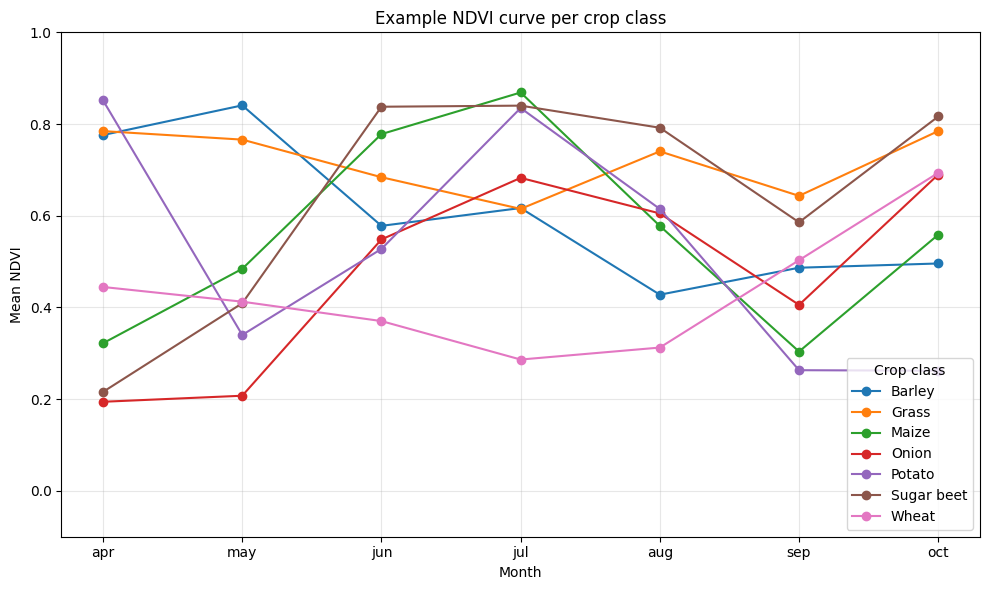

In [6]:
example_fields = (
    field_features
    .dropna(subset=ndvi_cols, how="all")
    .groupby("crop_class", group_keys=False)
    .sample(n=1, random_state=42)
)

fig, ax = plt.subplots(figsize=(10, 6))
for _, row in example_fields.iterrows():
    ax.plot(list(month_names.values()), row[ndvi_cols].astype(float), marker="o", label=row["crop_class"])

ax.set_title("Example NDVI curve per crop class")
ax.set_xlabel("Month")
ax.set_ylabel("Mean NDVI")
ax.set_ylim(-0.1, 1.0)
ax.grid(True, alpha=0.3)
ax.legend(title="Crop class")
plt.tight_layout()
plt.show()